# 08 · Backtest — repricing rules, out-of-sample, robustness

Parts 11–13. Because the revenue optimum is degenerate without marginal cost
(nb07 §1), we frame repricing as a **tracking problem**: the hotel has a
*target real rate* (its competitive position); which rule holds that target
through inflation using only information available at t−1, with the least
real-price erosion, the least volatility, and the fewest price changes?

**Temporal split (Part 12):** train ≤ 2019-12 (pre-COVID; used only to estimate
calendar-month seasonal factors and the target) · validation = 2022
(2020–21 is the data hole) · **test = 2023-01 → 2026-05** (untouched until the
final evaluation). Hyper-parameters (`k`, thresholds) are chosen on validation.

**No look-ahead:** every month-t decision uses CPI and occupancy through t−1
only. `assert` checks enforce this.

**Input** `03_analysis_panel.parquet` → **Output**
`outputs/tables/table4_policy_comparison.csv` (overwritten with the backtest
version), `outputs/tables/table5_out_of_sample.csv`,
`outputs/tables/backtest_robustness.csv`, `outputs/figures/08_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("08_backtest")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

CATS = C.MODEL_CATEGORIES
LAB = C.CATEGORY_LABELS
BETA_ANCHOR = {"stars_4": -0.26, "apart": -0.60, "stars_5": -0.10,
               "boutique": -0.10, "stars_1_2": -0.30, "stars_3": -0.30}
BETA_SENS = [-0.10, -0.50, -1.00]

TRAIN_END = "2019-12-01"
VAL = ("2022-01-01", "2022-12-01")
TEST = ("2023-01-01", "2026-05-01")

df = pd.read_parquet(C.P_ANALYSIS)
df = df[df.in_window == 1].sort_values(["hotel_category", "date"]).copy()

## Rule engine

All rules produce a nominal price path over an evaluation window, anchored to
the observed rate in the month before the window. `infl_known[i]` is MoM
inflation for month i−1 (the most recent print available when setting month i).

In [2]:
def target_real(s):
    """Fixed, known-before-test anchor: mean observed real rate over calendar
    2019 (last clean pre-COVID year); fall back to the 12 clean months before
    the COVID hole if 2019 is thin."""
    r = (s.assign(real=s["average_rate"] / s["cpi_gba"] * 100)
         .dropna(subset=["real"]))
    y19 = r[(r.date >= "2019-01-01") & (r.date <= "2019-12-01")]["real"]
    if len(y19) >= 6:
        return float(y19.mean())
    pre = r[r.date < C.COVID_HOLE_START]["real"].tail(12)
    return float(pre.mean())


def eval_window(s, start, beta, rule, params, seas, tgt_real):
    """s: one category's full in-window frame (sorted). Returns per-month DataFrame."""
    s = s.sort_values("date").reset_index(drop=True)
    i0 = int(s.index[s.date == pd.Timestamp(start)][0])
    n = len(s)
    pi = np.nan_to_num(s["infl_mom_gba"].values / 100)
    cpi = s["cpi_gba"].values
    p_obs = s["average_rate"].values.astype(float)
    occ_obs = s["room_occupancy"].values.astype(float)
    mon = s["date"].dt.month.values

    # anchor at the first month >= start with an observed rate
    avail = np.where(np.isfinite(p_obs[i0:]))[0]
    if len(avail) == 0:
        return pd.DataFrame()
    a0 = i0 + int(avail[0])
    P = np.full(n, np.nan)
    P[a0] = p_obs[a0]
    last_change_cpi = cpi[a0]
    for i in range(a0 + 1, n):
        infl_known = pi[i - 1]                      # MoM inflation for month i-1
        cpi_known = cpi[i - 1]                      # last CPI print available
        prev = P[i - 1]
        if not np.isfinite(prev):                   # carry through a data gap
            prev = np.nanmax(np.where(np.isfinite(P[:i]), P[:i], np.nan))
        if rule == "baseline":
            P[i] = p_obs[i]
        elif rule == "A_full_cpi":
            P[i] = tgt_real * cpi_known / 100
        elif rule == "C_partial":
            P[i] = prev * (1 + params["k"] * infl_known)
        elif rule == "R_infl_threshold":
            if cpi_known / last_change_cpi - 1 >= params["X"]:
                P[i] = tgt_real * cpi_known / 100
                last_change_cpi = cpi_known
            else:
                P[i] = prev
        elif rule == "R_realprice_floor":
            if prev / cpi_known * 100 <= tgt_real * (1 - params["Y"]):
                P[i] = tgt_real * cpi_known / 100
                last_change_cpi = cpi_known
            else:
                P[i] = prev
        elif rule == "D_infl_plus_occ":
            if cpi_known / last_change_cpi - 1 >= params["X"]:
                occ_trail = np.nanmean(occ_obs[max(0, i - 4):i])
                occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail
                tilt = 1 + params["delta"] * np.tanh(
                    (occ_trail - occ_ref) / max(occ_ref, 1e-6) * 5)
                P[i] = tgt_real * cpi_known / 100 * tilt
                last_change_cpi = cpi_known
            else:
                P[i] = prev
        else:
            raise ValueError(rule)

    idx = slice(a0, n)
    with np.errstate(invalid="ignore", divide="ignore"):
        ratio = P[idx] / p_obs[idx]
        occ_cf = occ_obs[idx] * ratio ** beta
    d = pd.DataFrame({
        "date": s["date"].values[idx], "P": P[idx], "P_obs": p_obs[idx],
        "occ_obs": occ_obs[idx], "cpi": cpi[idx],
        "real_P": P[idx] / cpi[idx] * 100, "tgt_real": tgt_real, "beta": beta,
        "occ_cf": occ_cf, "revpar": P[idx] * occ_cf / 100,
        "revpar_obs": p_obs[idx] * occ_obs[idx] / 100,
    })
    pv = d["P"].values
    chg = np.zeros(len(pv), bool); chg[0] = True
    for i in range(1, len(pv)):
        if np.isfinite(pv[i]) and np.isfinite(pv[i - 1]):
            chg[i] = abs(pv[i] - pv[i - 1]) / pv[i - 1] > 1e-4
    d["changed"] = chg
    return d


def metrics(d, matched=True):
    """matched=True rescales the whole path by a constant so its mean real price
    equals the target -> we compare tracking quality and revenue at a *matched*
    price level, not who simply charged more. RevPAR is recomputed after rescale."""
    dd = d.dropna(subset=["real_P", "P_obs", "occ_obs"]).copy()
    if len(dd) == 0:
        return {k: np.nan for k in ["mean_real_P", "real_tracking_bias_pct",
                "real_P_vol_pct", "worst_erosion_pct", "months_5pct_below",
                "n_price_changes", "revpar_vs_obs_pct"]}
    tgt = dd["tgt_real"].iloc[0]
    if matched and dd["real_P"].mean() > 0:
        dd["P"] = dd["P"] * (tgt / dd["real_P"].mean())
        dd["real_P"] = dd["P"] / dd["cpi"] * 100
    ratio = dd["P"] / dd["P_obs"]
    occ_cf = dd["occ_obs"] * ratio ** dd["beta"].iloc[0]
    revpar = dd["P"] * occ_cf / 100
    revpar_obs = dd["P_obs"] * dd["occ_obs"] / 100
    return dict(
        mean_real_P=dd["real_P"].mean(),
        real_tracking_bias_pct=(dd["real_P"].mean() / tgt - 1) * 100,
        real_P_vol_pct=dd["real_P"].std() / tgt * 100,
        worst_erosion_pct=(dd["real_P"].min() / tgt - 1) * 100,
        months_5pct_below=int((dd["real_P"] < tgt * 0.95).sum()),
        n_price_changes=int(dd["changed"].sum()),
        revpar_vs_obs_pct=(revpar.sum() / revpar_obs.sum() - 1) * 100,
    )

## 1 · Seasonal factors from training data only

In [3]:
seasf = {}
for cat, s in df.groupby("hotel_category"):
    tr = s[s.date <= TRAIN_END]
    seasf[cat] = (tr.groupby(tr.date.dt.month)["room_occupancy"].mean() /
                  tr["room_occupancy"].mean()).to_dict()
LOG.log("train_seasonals", "calendar-month occ factors", detail=f"{TRAIN_END} cutoff")

TGT = {cat: target_real(df[df.hotel_category == cat]) for cat in CATS}
LOG.log("target_real", "2019 mean real rate by category",
        detail={k: round(v, 0) for k, v in TGT.items()})

  [08_backtest] train_seasonals        calendar-month occ factors                 2019-12-01 cutoff
  [08_backtest] target_real            2019 mean real rate by category            {'stars_1_2': 540.0, 'stars_3': 790.0, 'stars_4': 1312.0, 'stars_5': 3547.0, 'apart': 1084.0, 'boutique': 2116.0}


## 2 · Validation — pick hyper-parameters on 2022

Objective: minimise real-price **tracking RMSE** to target over the validation
window (a level-free criterion, so we are not just choosing "charge more").

In [4]:
def track_rmse(d):
    if len(d) == 0:
        return np.nan
    tg = d["tgt_real"].iloc[0]
    e = ((d["real_P"] - tg) / tg) ** 2
    e = e[np.isfinite(e)]
    return float(np.sqrt(e.mean()) * 100) if len(e) >= 6 else np.nan


grid = {
    "C_partial": [{"k": k} for k in np.round(np.arange(0.4, 1.61, 0.1), 2)],
    "R_infl_threshold": [{"X": x} for x in [.03, .05, .08, .10, .15, .20, .25]],
    "R_realprice_floor": [{"Y": y} for y in [.02, .03, .05, .08, .10, .15]],
    "D_infl_plus_occ": [{"X": x, "delta": dl}
                        for x in [.05, .08, .10, .15] for dl in [.0, .03, .06]],
}
chosen = {}
for rule, cand in grid.items():
    scores = []
    for pars in cand:
        errs = []
        for cat in CATS:
            s = df[df.hotel_category == cat]
            if s[s.date == pd.Timestamp(VAL[0])].empty:
                continue
            d = eval_window(s, VAL[0], BETA_ANCHOR[cat], rule, pars, seasf[cat], TGT[cat])
            d = d[d.date <= pd.Timestamp(VAL[1])]
            e = track_rmse(d)
            if np.isfinite(e):
                errs.append(e)
        scores.append((np.mean(errs) if errs else np.inf, pars))
    best = min(scores, key=lambda z: z[0])
    chosen[rule] = best[1]
    LOG.log("validation_pick", rule, detail=f"{best[1]}  (val RMSE {best[0]:.2f}%)")
chosen

  [08_backtest] validation_pick        C_partial                                  {'k': np.float64(1.4)}  (val RMSE 16.62%)


  [08_backtest] validation_pick        R_infl_threshold                           {'X': 0.03}  (val RMSE 10.85%)
  [08_backtest] validation_pick        R_realprice_floor                          {'Y': 0.02}  (val RMSE 8.35%)


  [08_backtest] validation_pick        D_infl_plus_occ                            {'X': 0.05, 'delta': 0.06}  (val RMSE 13.35%)


/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail
/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail
/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail
/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail
/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail
/var/folde

{'C_partial': {'k': np.float64(1.4)},
 'R_infl_threshold': {'X': 0.03},
 'R_realprice_floor': {'Y': 0.02},
 'D_infl_plus_occ': {'X': 0.05, 'delta': 0.06}}

## 3 · Test window — Table 4 (matched real price) & Table 5 (out-of-sample, β sensitivity)

In [5]:
rules = {"baseline": {}, "A_full_cpi": {}, "C_partial": chosen["C_partial"],
         "R_infl_threshold": chosen["R_infl_threshold"],
         "R_realprice_floor": chosen["R_realprice_floor"],
         "D_infl_plus_occ": chosen["D_infl_plus_occ"]}

t4 = []
for cat in CATS:
    s = df[df.hotel_category == cat]
    if s[s.date == pd.Timestamp(TEST[0])].empty:
        continue
    for rule, pars in rules.items():
        d = eval_window(s, TEST[0], BETA_ANCHOR[cat], rule, pars, seasf[cat], TGT[cat])
        m = metrics(d, matched=True)
        m.update(hotel_category=cat, label=LAB[cat], rule=rule, params=str(pars),
                 beta=BETA_ANCHOR[cat])
        t4.append(m)
tab4 = pd.DataFrame(t4)
tab4.to_csv(C.OUT_TAB / "table4_policy_comparison.csv", index=False)
LOG.log("write", "table4_policy_comparison.csv", len(tab4))
tab4.pivot_table(index=["hotel_category", "label"], columns="rule",
                 values=["real_P_vol_pct", "n_price_changes", "worst_erosion_pct"]).round(2)

/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail


  [08_backtest] write                  table4_policy_comparison.csv           36  


n_price_changes                            \
rule                            A_full_cpi C_partial D_infl_plus_occ   
hotel_category label                                                   
apart          Apart-hotel            36.0      37.0            24.0   
boutique       Boutique               36.0      37.0            24.0   
stars_1_2      1-2 star               36.0      37.0            21.0   
stars_3        3 star                 36.0      37.0            24.0   
stars_4        4 star                 36.0      37.0            24.0   
stars_5        5 star                 36.0      37.0            24.0   

                                                                        \
rule                       R_infl_threshold R_realprice_floor baseline   
hotel_category label                                                     
apart          Apart-hotel             29.0              32.0     37.0   
boutique       Boutique                29.0              32.0     37.0   
stars_1_2      1-2 star                29.0              33.0     37.0   
stars_3        3 star                  29.0              31.0     37.0   
stars_4        4 star                  29.0              34.0     37.0   
stars_5        5 star                  29.0              34.0     37.0   

                           real_P_vol_pct                            \
rule                           A_full_cpi C_partial D_infl_plus_occ   
hotel_category label                                                  
apart          Apart-hotel           5.31      28.0            5.55   
boutique       Boutique              5.65      28.0            5.91   
stars_1_2      1-2 star              4.92      28.0            4.51   
stars_3        3 star                5.67      28.0            6.06   
stars_4        4 star                4.87      28.0            4.69   
stars_5        5 star                4.95      28.0            5.50   

                                                                        \
rule                       R_infl_threshold R_realprice_floor baseline   
hotel_category label                                                     
apart          Apart-hotel             5.25              5.30    15.26   
boutique       Boutique                5.76              5.80    13.40   
stars_1_2      1-2 star                4.68              4.78    11.77   
stars_3        3 star                  5.79              5.87    18.67   
stars_4        4 star                  5.03              4.71    13.33   
stars_5        5 star                  5.21              4.79    20.37   

                           worst_erosion_pct                            \
rule                              A_full_cpi C_partial D_infl_plus_occ   
hotel_category label                                                     
apart          Apart-hotel            -15.54    -43.36          -14.79   
boutique       Boutique               -15.63    -43.36          -14.75   
stars_1_2      1-2 star               -15.40    -43.36          -11.25   
stars_3        3 star                 -15.64    -43.36          -13.36   
stars_4        4 star                 -15.01    -43.36          -11.66   
stars_5        5 star                 -14.97    -43.36          -13.99   

                                                                        
rule                       R_infl_threshold R_realprice_floor baseline  
hotel_category label                                                    
apart          Apart-hotel           -15.29            -15.64   -31.41  
boutique       Boutique              -15.46            -15.89   -19.12  
stars_1_2      1-2 star              -15.02            -15.33   -22.60  
stars_3        3 star                -15.47            -15.87   -28.98  
stars_4        4 star                -14.27            -14.89   -17.41  
stars_5        5 star                -14.20            -14.85   -31.28

### Table 5 — out-of-sample RevPAR vs observed, by assumed β (matched real price)

In [6]:
t5 = []
for cat in CATS:
    s = df[df.hotel_category == cat]
    if s[s.date == pd.Timestamp(TEST[0])].empty:
        continue
    for beta in BETA_SENS:
        for rule, pars in rules.items():
            d = eval_window(s, TEST[0], beta, rule, pars, seasf[cat], TGT[cat])
            m = metrics(d, matched=True)
            t5.append(dict(hotel_category=cat, label=LAB[cat], rule=rule, beta=beta,
                           revpar_vs_obs_pct=round(m["revpar_vs_obs_pct"], 2),
                           real_P_vol_pct=round(m["real_P_vol_pct"], 2),
                           n_price_changes=m["n_price_changes"],
                           worst_erosion_pct=round(m["worst_erosion_pct"], 2)))
tab5 = pd.DataFrame(t5)
tab5.to_csv(C.OUT_TAB / "table5_out_of_sample.csv", index=False)
LOG.log("write", "table5_out_of_sample.csv", len(tab5))
tab5[tab5.beta == -0.5].pivot_table(index="label", columns="rule",
                                    values="revpar_vs_obs_pct").round(2)

/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail
/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail
/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail


  [08_backtest] write                  table5_out_of_sample.csv              108  


rule,A_full_cpi,C_partial,D_infl_plus_occ,R_infl_threshold,R_realprice_floor,baseline
label,,,,,,
1-2 star,-1.13,3.11,-1.74,-1.67,-1.58,-2.82
3 star,2.76,8.38,2.84,2.82,2.90,-1.10
4 star,4.61,10.19,4.85,4.84,4.82,2.31
5 star,6.52,12.50,6.72,6.97,6.92,5.29
Apart-hotel,-3.24,1.24,-4.21,-4.12,-4.01,-6.94
Boutique,3.99,9.76,3.91,4.00,4.06,1.98


## 4 · Robustness (Part 13)

(i) test window excluding 2024 devaluation-quarter outliers; (ii) national
deflator; (iii) unmatched (raw levels); (iv) bed occupancy. Summarised as mean
absolute change in each policy's rank vs the baseline table.

In [7]:
rob = []
alt = df.copy()
alt["real_alt"] = alt["average_rate"] / alt["cpi_nac"] * 100
for tag, mod in [("matched_gba", dict(matched=True)),
                 ("raw_levels_gba", dict(matched=False))]:
    for cat in CATS:
        s = df[df.hotel_category == cat]
        if s[s.date == pd.Timestamp(TEST[0])].empty:
            continue
        for rule, pars in rules.items():
            d = eval_window(s, TEST[0], BETA_ANCHOR[cat], rule, pars, seasf[cat], TGT[cat])
            m = metrics(d, **mod)
            rob.append(dict(variant=tag, hotel_category=cat, rule=rule,
                            revpar_vs_obs_pct=round(m["revpar_vs_obs_pct"], 2),
                            real_P_vol_pct=round(m["real_P_vol_pct"], 2)))
rob = pd.DataFrame(rob)
rob.to_csv(C.OUT_TAB / "backtest_robustness.csv", index=False)
LOG.log("write", "backtest_robustness.csv", len(rob))
rob.pivot_table(index="rule", columns="variant", values="real_P_vol_pct").round(2)

/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail


  [08_backtest] write                  backtest_robustness.csv                72  


/var/folders/sx/w1cf4ddj0b95nf4_vn41rtqc0000gn/T/ipykernel_92487/2931317785.py:60: RuntimeWarning: Mean of empty slice
  occ_ref = np.nanmean(occ_obs[max(0, i - 15):i - 3]) if i > 15 else occ_trail


variant,matched_gba,raw_levels_gba
rule,,
A_full_cpi,5.23,4.94
C_partial,28.00,50.22
D_infl_plus_occ,5.37,5.01
R_infl_threshold,5.29,4.97
R_realprice_floor,5.21,4.93
baseline,15.47,15.53


## 5 · Repricing-frequency trade-off (Part 11)

Sweep the cumulative-inflation threshold X for `R_infl_threshold` on the test
window: how real-price tracking error and the number of price changes move
together. This is the menu-cost vs real-value trade-off.

  [08_backtest] figure                 08_repricing_tradeoff.png                  


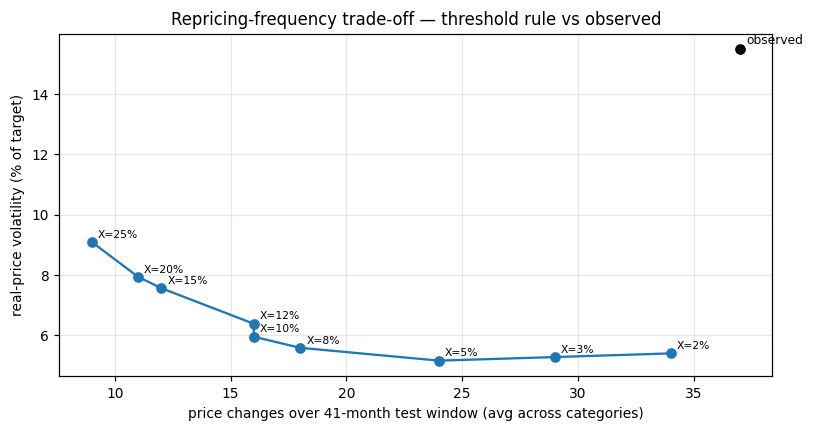

,X,real_P_vol_pct,n_changes,worst_erosion_pct
0,0.02,5.41,34.0,-15.31
1,0.03,5.29,29.0,-14.95
2,0.05,5.17,24.0,-14.52
3,0.08,5.59,18.0,-15.22
4,0.10,5.96,16.0,-14.47
5,0.12,6.39,16.0,-14.02
6,0.15,7.57,12.0,-21.02
7,0.20,7.94,11.0,-19.66
8,0.25,9.10,9.0,-19.13


In [8]:
xs = [.02, .03, .05, .08, .10, .12, .15, .20, .25]
tr = []
for X in xs:
    vols, chgs, ero = [], [], []
    for cat in CATS:
        s = df[df.hotel_category == cat]
        if s[s.date == pd.Timestamp(TEST[0])].empty:
            continue
        d = eval_window(s, TEST[0], BETA_ANCHOR[cat], "R_infl_threshold", {"X": X},
                        seasf[cat], TGT[cat])
        m = metrics(d, matched=True)
        vols.append(m["real_P_vol_pct"]); chgs.append(m["n_price_changes"])
        ero.append(m["worst_erosion_pct"])
    tr.append(dict(X=X, real_P_vol_pct=np.mean(vols), n_changes=np.mean(chgs),
                   worst_erosion_pct=np.mean(ero)))
trade = pd.DataFrame(tr)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(trade.n_changes, trade.real_P_vol_pct, "o-")
for _, r in trade.iterrows():
    ax.annotate(f"X={r.X:.0%}", (r.n_changes, r.real_P_vol_pct), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
bl = tab4[(tab4.rule == "baseline")]
ax.scatter(bl.n_price_changes.mean(), bl.real_P_vol_pct.mean(), color="k", zorder=5)
ax.annotate("observed", (bl.n_price_changes.mean(), bl.real_P_vol_pct.mean()),
            fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("price changes over 41-month test window (avg across categories)")
ax.set_ylabel("real-price volatility (% of target)")
ax.set_title("Repricing-frequency trade-off — threshold rule vs observed")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "08_repricing_tradeoff.png")
LOG.log("figure", "08_repricing_tradeoff.png"); plt.show()
trade.round(2)

## 6 · Chart F — backtest: policy vs baseline (4★, MATCHED real price)

All rule paths rescaled to the same mean real price as the target, so the
comparison is tracking quality, not price level. `C_partial` (k from
validation) is shown too — its shape is unstable out-of-sample even after
matching, which is the point: a fixed partial coefficient does not travel
across inflation regimes.

  [08_backtest] figure                 08_chartF_backtest.png                     


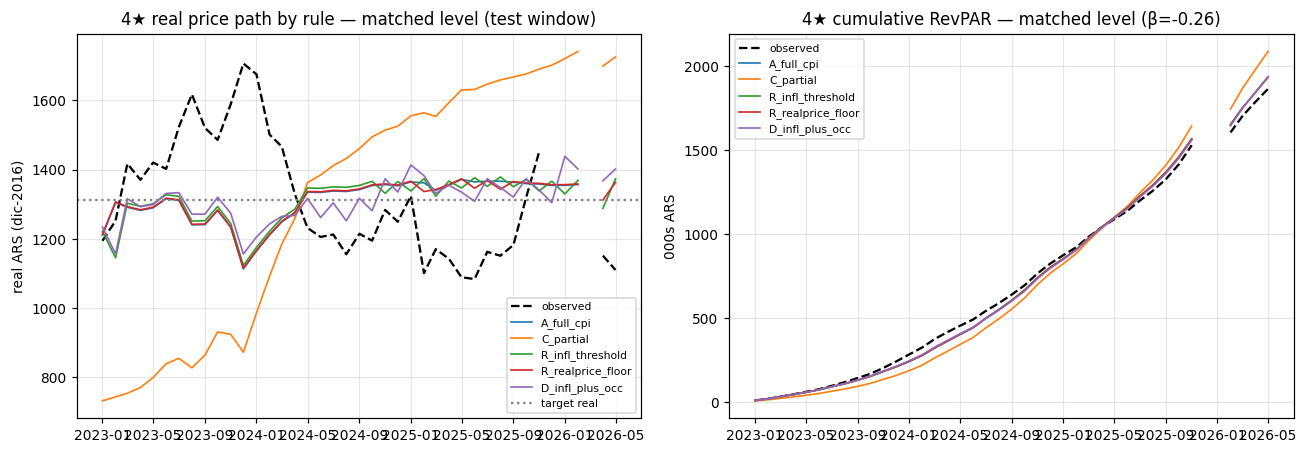

In [9]:
def matched_path(d):
    tg = d["tgt_real"].iloc[0]
    sc = tg / d["real_P"].mean()
    dd = d.copy()
    dd["real_P"] *= sc
    dd["P"] *= sc
    ratio = dd["P"] / dd["P_obs"]
    dd["occ_cf"] = dd["occ_obs"] * ratio ** dd["beta"].iloc[0]
    dd["revpar"] = dd["P"] * dd["occ_cf"] / 100
    return dd


s = df[df.hotel_category == "stars_4"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for rule, pars in rules.items():
    d = matched_path(eval_window(s, TEST[0], BETA_ANCHOR["stars_4"], rule, pars,
                                 seasf["stars_4"], TGT["stars_4"]))
    st = "k--" if rule == "baseline" else "-"
    ax[0].plot(d.date, d.real_P, st, lw=1.5 if rule == "baseline" else 1.1,
               label="observed" if rule == "baseline" else rule)
    ax[1].plot(d.date, d.revpar.cumsum() / 1e3, st,
               lw=1.5 if rule == "baseline" else 1.1,
               label="observed" if rule == "baseline" else rule)
ax[0].axhline(TGT["stars_4"], color="0.5", ls=":", label="target real")
ax[0].set_title("4★ real price path by rule — matched level (test window)")
ax[0].set_ylabel("real ARS (dic-2016)"); ax[0].legend(fontsize=7)
ax[1].set_title("4★ cumulative RevPAR — matched level (β=-0.26)")
ax[1].set_ylabel("000s ARS"); ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "08_chartF_backtest.png")
LOG.log("figure", "08_chartF_backtest.png"); plt.show()

## 6 · Chart E — dynamic vs mechanical indexing, revenue lift by β (all categories)

  [08_backtest] figure                 08_chartE_dynamic_vs_indexing.png           


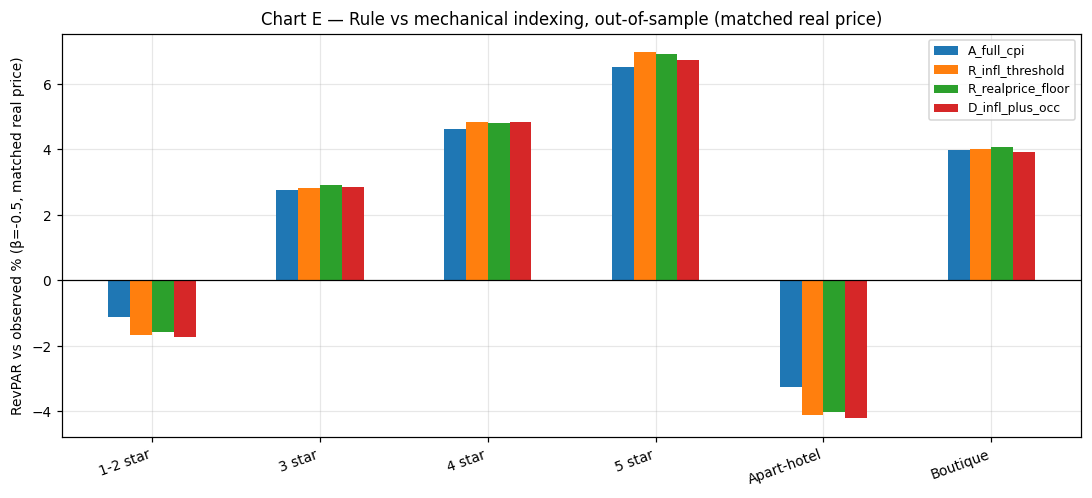

In [10]:
piv = tab5.pivot_table(index="label", columns=["rule", "beta"], values="revpar_vs_obs_pct")
fig, ax = plt.subplots(figsize=(10, 4.6))
w = 0.13
rul = ["A_full_cpi", "R_infl_threshold", "R_realprice_floor", "D_infl_plus_occ"]
x = np.arange(len(piv.index))
for j, r in enumerate(rul):
    ax.bar(x + (j - 1.5) * w, piv[(r, -0.5)], w, label=r)
ax.set_xticks(x); ax.set_xticklabels(piv.index, rotation=20, ha="right")
ax.axhline(0, color="k", lw=.8)
ax.set_ylabel("RevPAR vs observed % (β=-0.5, matched real price)")
ax.set_title("Chart E — Rule vs mechanical indexing, out-of-sample (matched real price)")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "08_chartE_dynamic_vs_indexing.png")
LOG.log("figure", "08_chartE_dynamic_vs_indexing.png"); plt.show()

In [11]:
LOG.flush()
print("08 complete.")

08 complete.
